In [1]:
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib_inline
matplotlib_inline.backend_inline.set_matplotlib_formats('svg')
import seaborn as sns

In [2]:
# BOOK_FIGURE_STYLE_CELL
from pathlib import Path

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

try:
    import seaborn as sns
except ImportError:
    sns = None

try:
    import matplotlib_inline

    matplotlib_inline.backend_inline.set_matplotlib_formats("svg")
except Exception:
    matplotlib_inline = None

FIGURE_SIZES = {
    "full_landscape": (7.35, 4.40),
    "full_standard": (7.35, 4.90),
    "full_tall": (7.35, 5.50),
    "half_standard": (3.55, 2.55),
    "half_tall": (3.55, 3.05),
    "inset": (2.30, 1.75),
}

BOOK_COLORS = {
    "blue": "#4C78A8",
    "orange": "#F58518",
    "green": "#54A24B",
    "red": "#E45756",
    "gray": "#7F7F7F",
}

BOOK_TARGET = "web"


def setup_book_style(target="web"):
    global BOOK_TARGET
    BOOK_TARGET = target
    mpl.rcParams.update(
        {
            "figure.figsize": FIGURE_SIZES["half_standard"],
            "figure.dpi": 120,
            "savefig.dpi": 300,
            "savefig.bbox": "tight",
            "savefig.pad_inches": 0.02,
            "font.family": "sans-serif",
            "font.sans-serif": ["DejaVu Sans", "Arial", "Liberation Sans"],
            "axes.labelsize": 9,
            "axes.titlesize": 9,
            "axes.linewidth": 0.8,
            "axes.grid": False,
            "axes.spines.top": False,
            "axes.spines.right": False,
            "xtick.labelsize": 8,
            "ytick.labelsize": 8,
            "xtick.major.width": 0.8,
            "ytick.major.width": 0.8,
            "legend.fontsize": 8,
            "legend.frameon": False,
            "lines.linewidth": 1.5,
            "lines.markersize": 4,
            "patch.linewidth": 0.8,
            "image.cmap": "viridis",
        }
    )
    if target == "latex":
        try:
            mpl.rcParams["text.usetex"] = False
        except Exception:
            mpl.rcParams["text.usetex"] = False


def new_figure(
    size="half_standard",
    nrows=1,
    ncols=1,
    sharex=False,
    sharey=False,
    constrained=True,
    squeeze=True,
    **kwargs,
):
    fig, ax = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        sharex=sharex,
        sharey=sharey,
        constrained_layout=constrained,
        figsize=FIGURE_SIZES[size],
        squeeze=squeeze,
        **kwargs,
    )
    return fig, ax


def label_panels(axes=None, labels=None, x=0.02, y=0.98, **kwargs):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    if labels is None:
        labels = [f"({chr(97 + i)})" for i in range(len(axes))]
    default = dict(
        fontsize=9,
        fontweight="semibold",
        va="top",
        ha="left",
        transform=None,
    )
    default.update(kwargs)
    for ax, label in zip(axes, labels):
        call_kwargs = dict(default)
        if call_kwargs["transform"] is None:
            call_kwargs["transform"] = ax.transAxes
        ax.text(x, y, label, **call_kwargs)


def finalize_axes(axes=None, keep_box=False, grid=False):
    if axes is None:
        axes = plt.gcf().axes
    axes = np.atleast_1d(axes).ravel()
    for ax in axes:
        if grid:
            ax.grid(axis="y", color="0.88", linewidth=0.6)
        else:
            ax.grid(False)
        for spine in ax.spines.values():
            spine.set_linewidth(0.8)
        if keep_box:
            ax.spines["top"].set_visible(True)
            ax.spines["right"].set_visible(True)
        else:
            ax.spines["top"].set_visible(False)
            ax.spines["right"].set_visible(False)
    return axes


def save_book_figure(fig, basename, target="web", pdf=True, png=False):
    base = Path(basename)
    base.parent.mkdir(parents=True, exist_ok=True)
    if pdf:
        fig.savefig(base.with_suffix(".pdf"), bbox_inches="tight", pad_inches=0.02)
    if png:
        fig.savefig(base.with_suffix(".png"), bbox_inches="tight", pad_inches=0.02)


setup_book_style(target="web")


# SINDy Example 1: Linear and Cubic Systems


Sparse Identification of Nonlinear Dynamics (SINDy) is a method to identify the governing equations of a dynamical system from data.
The method was introduced by {cite:t}`brunton2016discovering` and has since become widely used.
The [SINDy theory section](02_sindy_theory.md) develops the feature library, sparse regression, and identifiability conditions used here.
Here we will replicate the results of the paper.
For further details, see the appendix of {cite:t}`brunton2016discovering`.



## Example 1ai: Linear dynamics

Consider the linear system:


\begin{align}
\dot{x}_1 &= -0.1 x_1 + 2 x_2 \\
\dot{x}_2 &= -2 x_1 - 0.1 x_2
\end{align}


We will generate data from this system without noise, fit a high dimensional polynomial of fifth order and see if we can identify the coefficients correctly.

In [3]:
import numpy as np
import scipy

A = np.array([
    [-0.1, 2],
    [-2, -0.1]
])

ts = np.linspace(0.0, 25.0, 10_000)
x0 = np.array([2.0, 0.0])
xs = scipy.integrate.odeint(lambda x, t: A @ x, x0, ts)
dxs = A @ xs.T

Let's set up the regression problem.
We are going to solve a different one for $x_1$ and $x_2$.
We write:

$$
\dot{x}_j = f_j(\mathbf{x}) = \boldsymbol{\phi}^T(\mathbf{x})\boldsymbol{\theta}_j,
$$

where $\boldsymbol{\phi}(\mathbf{x})$ is a two-dimensional polynomial of fifth order and $\boldsymbol{\theta}_j$ are the coefficients we want to identify.

We will fit $\boldsymbol{\theta}_j$ by solving the following optimization problem:

$$
\min_{\boldsymbol{\theta}_j} \left\{
\|\dot{X}_j - \Phi\boldsymbol{\theta}_j\|^2 + \lambda \|\boldsymbol{\theta}_j\|_1
\right\},
$$

where $\dot{X}_j$ is the time derivative of $x_j$ and $\Phi$ is the matrix of $\boldsymbol{\phi}(\mathbf{x})$ evaluated at the data points (the design matrix).

In [4]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LassoCV

f_approx = PolynomialFeatures(degree=5)
Phi = f_approx.fit_transform(xs)

thetas = []
for j in range(2):
    clf = LassoCV(fit_intercept=False, alphas=10_000, eps=1e-5)
    dx = dxs[j, :]
    clf.fit(Phi, dx)
    thetas.append(clf.coef_)

And here are how the coefficients compare:

In [5]:
for j in range(2):
    print(f"Dynamics of x_{j+1}:")
    print("-" * 20)
    for i, name in enumerate(f_approx.get_feature_names_out()):
        print(f"{name:10} = {thetas[j][i]:.2f}")  

Dynamics of x_1:
--------------------
1          = 0.00
x0         = -0.10
x1         = 2.00
x0^2       = -0.00
x0 x1      = 0.00
x1^2       = 0.00
x0^3       = -0.00
x0^2 x1    = 0.00
x0 x1^2    = -0.00
x1^3       = 0.00
x0^4       = -0.00
x0^3 x1    = 0.00
x0^2 x1^2  = -0.00
x0 x1^3    = 0.00
x1^4       = 0.00
x0^5       = -0.00
x0^4 x1    = 0.00
x0^3 x1^2  = -0.00
x0^2 x1^3  = 0.00
x0 x1^4    = -0.00
x1^5       = 0.00
Dynamics of x_2:
--------------------
1          = 0.00
x0         = -2.00
x1         = -0.10
x0^2       = 0.00
x0 x1      = -0.00
x1^2       = -0.00
x0^3       = -0.00
x0^2 x1    = -0.00
x0 x1^2    = -0.00
x1^3       = -0.00
x0^4       = -0.00
x0^3 x1    = -0.00
x0^2 x1^2  = 0.00
x0 x1^3    = -0.00
x1^4       = -0.00
x0^5       = 0.00
x0^4 x1    = -0.00
x0^3 x1^2  = 0.00
x0^2 x1^3  = -0.00
x0 x1^4    = -0.00
x1^5       = -0.00


We observe an almost perfect identification of the dynamics.

Let's simulate the learned dynamics to see what we get.

In [6]:
def f_learned(x, t, thetas, f_approx):
    phi = f_approx.fit_transform(x.reshape(1, -1)).flatten()
    dx = np.zeros(x.shape[0])
    for j in range(x.shape[0]):
        dx[j] = np.dot(thetas[j], phi)
    return dx

xs_learned = scipy.integrate.odeint(lambda x, t: f_learned(x, t, thetas, f_approx), x0, ts)

Let's visualize the results:

array([<Axes: xlabel='Time', ylabel='$x_j$'>, <Axes: >], dtype=object)

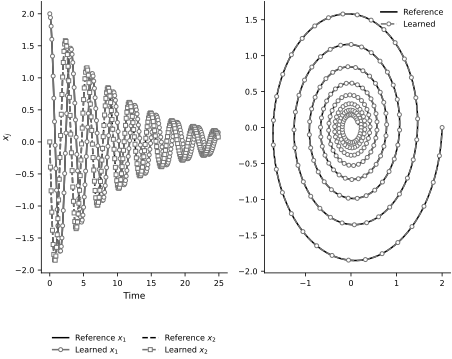

In [7]:
fig, ax = plt.subplots(1,2, figsize=FIGURE_SIZES["full_standard"])
component_styles = ['-', '--']
component_markers = ['o', 's']
for j in range(2):
    ax[0].plot(ts, xs[:, j], color='black', linestyle=component_styles[j],
               label=rf'Reference $x_{j+1}$')
    ax[0].plot(ts, xs_learned[:, j], color='0.45', linestyle=component_styles[j],
               marker=component_markers[j], markevery=40, markerfacecolor='white',
               label=rf'Learned $x_{j+1}$')
ax[0].set(xlabel="Time", ylabel="$x_j$")
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)

ax[1].plot(xs[:,0], xs[:,1], color='black', linestyle='-', label='Reference')
ax[1].plot(xs_learned[:,0], xs_learned[:,1], color='0.45', linestyle='--',
           marker='o', markevery=40, markerfacecolor='white', label='Learned')
ax[1].legend(loc='best')

finalize_axes(keep_box=False)

This reproduces the left column of Fig. 2 in the appendix of {cite:t}`brunton2016discovering`.

## Example 1aii: Cubic non-linearity

This example is as above, but with a cubic non-linearity:


\begin{align}
\dot{x}_1 &= -0.1 x_1^3 + 2 x_2^3 \\
\dot{x}_2 &= -2 x_1^3 - 0.1 x_2^3
\end{align}


Let's generate the data:

In [8]:
xs = scipy.integrate.odeint(lambda x, t: A @ (x ** 3), x0, ts)
dxs = A @ (xs ** 3).T

We fit the fifth degree polynomial just like before:

In [9]:
Phi = f_approx.fit_transform(xs)

thetas = []
for j in range(2):
    clf = LassoCV(fit_intercept=False, alphas=10_000, eps=1e-5)
    dx = dxs[j, :]
    clf.fit(Phi, dx)
    thetas.append(clf.coef_)

The coefficients:

In [10]:
for j in range(2):
    print(f"Dynamics of x_{j+1}:")
    print("-" * 20)
    for i, name in enumerate(f_approx.get_feature_names_out()):
        print(f"{name:10} = {thetas[j][i]:.2f}")  

Dynamics of x_1:
--------------------
1          = 0.00
x0         = -0.00
x1         = 0.00
x0^2       = 0.00
x0 x1      = -0.00
x1^2       = 0.00
x0^3       = -0.09
x0^2 x1    = 0.00
x0 x1^2    = -0.00
x1^3       = 1.99
x0^4       = 0.00
x0^3 x1    = -0.00
x0^2 x1^2  = 0.00
x0 x1^3    = -0.00
x1^4       = 0.00
x0^5       = -0.00
x0^4 x1    = 0.00
x0^3 x1^2  = -0.00
x0^2 x1^3  = 0.00
x0 x1^4    = -0.00
x1^5       = 0.00
Dynamics of x_2:
--------------------
1          = 0.00
x0         = -0.00
x1         = -0.00
x0^2       = 0.00
x0 x1      = -0.00
x1^2       = -0.00
x0^3       = -1.99
x0^2 x1    = -0.00
x0 x1^2    = -0.00
x1^3       = -0.10
x0^4       = 0.00
x0^3 x1    = -0.00
x0^2 x1^2  = 0.00
x0 x1^3    = 0.00
x1^4       = -0.00
x0^5       = -0.00
x0^4 x1    = -0.00
x0^3 x1^2  = -0.00
x0^2 x1^3  = -0.00
x0 x1^4    = -0.00
x1^5       = -0.00


And here are the predictions:

array([<Axes: xlabel='Time', ylabel='$x_j$'>, <Axes: >], dtype=object)

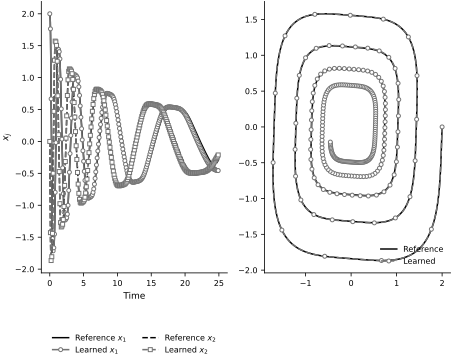

In [11]:
xs_learned = scipy.integrate.odeint(lambda x, t: f_learned(x, t, thetas, f_approx), x0, ts)

fig, ax = plt.subplots(1,2, figsize=FIGURE_SIZES["full_standard"])
component_styles = ['-', '--']
component_markers = ['o', 's']
for j in range(2):
    ax[0].plot(ts, xs[:, j], color='black', linestyle=component_styles[j],
               label=rf'Reference $x_{j+1}$')
    ax[0].plot(ts, xs_learned[:, j], color='0.45', linestyle=component_styles[j],
               marker=component_markers[j], markevery=40, markerfacecolor='white',
               label=rf'Learned $x_{j+1}$')
ax[0].set(xlabel="Time", ylabel="$x_j$")
ax[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=2)

ax[1].plot(xs[:,0], xs[:,1], color='black', linestyle='-', label='Reference')
ax[1].plot(xs_learned[:,0], xs_learned[:,1], color='0.45', linestyle='--',
           marker='o', markevery=40, markerfacecolor='white', label='Learned')
ax[1].legend(loc='best')

finalize_axes(keep_box=False)

This is the second column of Fig. 2 in the appendix of {cite:t}`brunton2016discovering`.

## Example 1b: Three-dimensional linear system

The system is:


\begin{align}
\dot{x}_1 &= -0.1 x_1 -2x_2\\
\dot{x}_2 &= 2x_1 -0.1x_2\\
\dot{x}_3 &= -0.3x_3
\end{align}


Generate synthetic data:

In [12]:
B = np.array([
    [-0.1, -2., 0],
    [2, -0.1, 0],
    [0, 0, -0.3]
])
ts = np.linspace(0, 50, 2_000)
x0 = np.array([2.0, 0.0, 1.0])
xs = scipy.integrate.odeint(lambda x, t: B @ x, x0, ts)
dxs = B @ xs.T

Fit:

In [13]:
Phi = f_approx.fit_transform(xs)
thetas = []
for j in range(3):
    clf = LassoCV(fit_intercept=False, alphas=10_000, eps=1e-5)
    dx = dxs[j, :]
    clf.fit(Phi, dx)
    thetas.append(clf.coef_)

Coefficients:

In [14]:
for j in range(3):
    print(f"Dynamics of x_{j+1}:")
    print("-" * 20)
    for i, name in enumerate(f_approx.get_feature_names_out()):
        print(f"{name:10} =  {thetas[j][i]:.2f}")

Dynamics of x_1:
--------------------
1          =  0.00
x0         =  -0.10
x1         =  -2.00
x2         =  -0.00
x0^2       =  -0.00
x0 x1      =  -0.00
x0 x2      =  -0.00
x1^2       =  0.00
x1 x2      =  -0.00
x2^2       =  -0.00
x0^3       =  -0.00
x0^2 x1    =  -0.00
x0^2 x2    =  -0.00
x0 x1^2    =  -0.00
x0 x1 x2   =  -0.00
x0 x2^2    =  -0.00
x1^3       =  -0.00
x1^2 x2    =  0.00
x1 x2^2    =  -0.00
x2^3       =  -0.00
x0^4       =  -0.00
x0^3 x1    =  -0.00
x0^3 x2    =  -0.00
x0^2 x1^2  =  -0.00
x0^2 x1 x2 =  -0.00
x0^2 x2^2  =  -0.00
x0 x1^3    =  -0.00
x0 x1^2 x2 =  -0.00
x0 x1 x2^2 =  -0.00
x0 x2^3    =  -0.00
x1^4       =  0.00
x1^3 x2    =  -0.00
x1^2 x2^2  =  -0.00
x1 x2^3    =  -0.00
x2^4       =  -0.00
x0^5       =  -0.00
x0^4 x1    =  -0.00
x0^4 x2    =  0.00
x0^3 x1^2  =  -0.00
x0^3 x1 x2 =  -0.00
x0^3 x2^2  =  -0.00
x0^2 x1^3  =  -0.00
x0^2 x1^2 x2 =  -0.00
x0^2 x1 x2^2 =  -0.00
x0^2 x2^3  =  -0.00
x0 x1^4    =  -0.00
x0 x1^3 x2 =  -0.00
x0 x1^2 x2^2 =  -0.00
x

Plots:

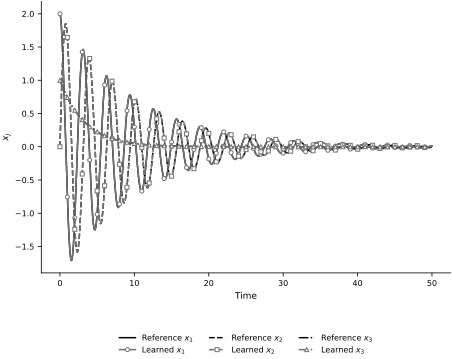

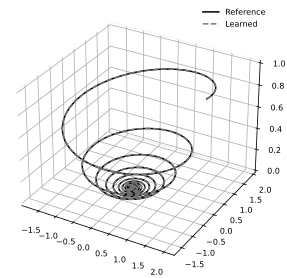

In [15]:
xs_learned = scipy.integrate.odeint(lambda x, t: f_learned(x, t, thetas, f_approx), x0, ts)

fig, ax = plt.subplots(figsize=FIGURE_SIZES["full_standard"])
component_styles = ['-', '--', '-.']
component_markers = ['o', 's', '^']
for j in range(3):
    ax.plot(ts, xs[:, j], color='black', linestyle=component_styles[j],
            label=rf'Reference $x_{j+1}$')
    ax.plot(ts, xs_learned[:, j], color='0.45', linestyle=component_styles[j],
            marker=component_markers[j], markevery=40, markerfacecolor='white',
            label=rf'Learned $x_{j+1}$')
ax.set(xlabel="Time", ylabel="$x_j$")
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.20), ncol=3)
finalize_axes(keep_box=False)

from mpl_toolkits.mplot3d import Axes3D
fig = plt.figure(figsize=FIGURE_SIZES["full_standard"])
ax = fig.add_subplot(111, projection='3d')
ax.plot(xs[:,0], xs[:,1], xs[:,2], color='black', linestyle='-', label='Reference')
ax.plot(xs_learned[:,0], xs_learned[:,1], xs_learned[:,2],
        color='0.45', linestyle='--', label='Learned')
ax.legend(loc='best')
ax.xaxis.pane.fill = False
ax.yaxis.pane.fill = False
ax.zaxis.pane.fill = False


This reproduces Fig. 3 in the appendix of {cite:t}`brunton2016discovering`.